In [1]:
rm processed/*

In [2]:
mkdir processed

mkdir: no se puede crear el directorio «processed»: El fichero ya existe


# Running the scripts

In [3]:
! cp MC/Protons/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 ./protons/

In [4]:
! cp MC/Gamma/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 ./GammaDiffuse/

In [5]:
! icmcsplit \
    -i GammaDiffuse/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 \
    -p processed/gamma_ \
    -f 0.5 0.5

In [6]:
! icmkmarkup \
    -i processed/gamma_part0.h5 \
    -o processed/gamma_part0_marked.h5 \
    -c 'gammaness > 0.7 & intensity > 50 & r < 1 & wl > 0.01 & wl < 1 & leakage_intensity_width_2 < 1' \
    -p 15 30 60
    
! icmkmarkup \
    -i processed/gamma_part1.h5 \
    -o processed/gamma_part1_marked.h5 \
    -c '' \
    -p 15 30 60

/home/silvia.garciasoto/.local/lib/python3.11/site-packages/iclass/markup.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'reco_offset'] = 180 / np.pi * angular_separation(
/home/silvia.garciasoto/.local/lib/python3.11/site-packages/iclass/markup.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['psf_class'] = -1


In [7]:
! ictrainmlp \
    -i processed/gamma_part0_marked.h5 \
    -p 'psf_' \
    -c "ic_mlp_std_config.json"

2026-04-08 13:50:42 iclass.mlp : INFO     Number of events for training: 55318
2026-04-08 13:50:42 iclass.mlp : INFO     Using features: ['log_intensity', 'width', 'length', 'wl', 'skewness', 'kurtosis', 'time_gradient', 'leakage_intensity_width_2', 'sin_az_tel', 'alt_tel']
2026-04-08 13:50:42 iclass.mlp : INFO     Training MLP Regressor for reco_offset ...
2026-04-08 13:50:58 iclass.mlp : INFO     Model MLPRegressor trained!
2026-04-08 13:51:11 iclass.scripts.ictrainmlp : INFO     Importance of the features according to permutation importance:
                     Feature  Importance
0              log_intensity    0.237310
6              time_gradient    0.120495
4                   skewness    0.098461
2                     length    0.052495
3                         wl    0.048383
5                   kurtosis    0.007204
7  leakage_intensity_width_2    0.006097
1                      width    0.000903
8                 sin_az_tel    0.000000
9                    alt_tel    0.00000

In [8]:
! icapplymlp \
    -i processed/gamma_part1_marked.h5 \
    -r 'psf_ic_mlp.pkl' \
    -p 'processed/ic_'

In [9]:
! icapplymlp \
    -i processed/gamma_part1_marked.h5 \
    -r 'psf_ic_mlp.pkl' \
    -c "/simulation/run_config" \
    -p 'processed/ic_' \
    --split \
    --partition 15 30 60

In [10]:
ls processed/

gamma_part0.h5                    ic_gamma_part1_marked_class1.h5
gamma_part0_marked.h5             ic_gamma_part1_marked_class2.h5
gamma_part1.h5                    ic_gamma_part1_marked_class3.h5
gamma_part1_marked.h5             ic_gamma_part1_marked_class4.h5
ic_gamma_part1_marked_class-1.h5  ic_gamma_part1_marked.h5


# Inspecting results

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [12]:
sample = pd.read_hdf(
    'processed/ic_gamma_part1_marked.h5', 
    key='/dl2/event/telescope/parameters/LST_LSTCam'
)
sample = sample.query('gammaness > 0.7 & intensity > 50 & r < 1 & wl > 0.01 & wl < 1 & leakage_intensity_width_2 < 1')

In [13]:
n_classes = len(np.unique(sample['psf_class']))
edges = 0.5 + np.arange(n_classes + 1)

In [ ]:
np.unique(sample['pred_psf_class'])

array([-1,  1,  2,  3,  4])

In [15]:
logE = sample['log_reco_energy']

energy_edges = np.arange(
    logE.min(),
    logE.max(),
    step=1 / 5
)
energy_edges

array([-1.48245586, -1.28245586, -1.08245586, -0.88245586, -0.68245586,
       -0.48245586, -0.28245586, -0.08245586,  0.11754414,  0.31754414,
        0.51754414,  0.71754414,  0.91754414,  1.11754414,  1.31754414,
        1.51754414])

In [ ]:
counts, _, _ = np.histogram2d(
    sample['psf_class'].values,
    sample['pred_psf_class'].values,
    bins=(edges, edges)
)

density = counts / counts.sum(axis=1)[..., None]

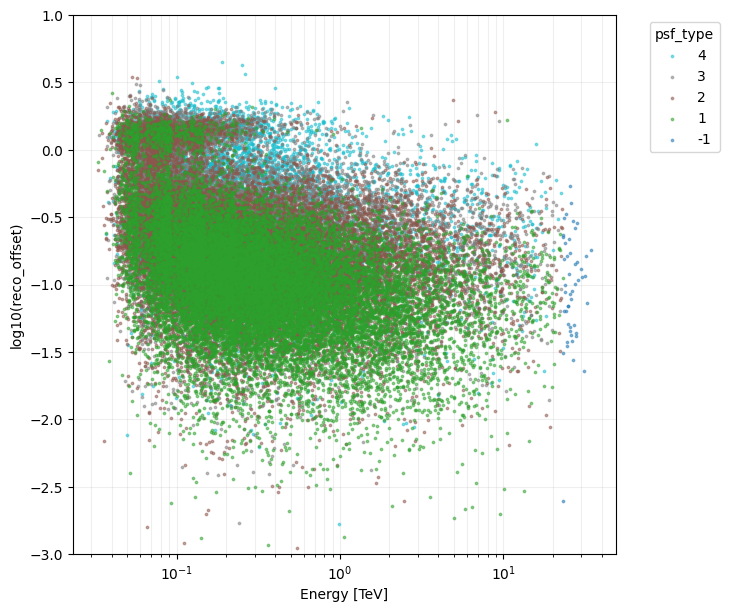

In [ ]:
classes = np.sort(sample["pred_psf_class"].dropna().unique())
n_classes = len(classes)

cmap = plt.get_cmap("tab10", n_classes)

plt.figure(figsize=(7, 7))
# plot from highest → lowest so 1 is on top
for i, cls in reversed(list(enumerate(classes))):
    mask = sample["pred_psf_class"] == cls

    # x: convert log_energy → energy
    x_vals = 10 ** sample.loc[mask, "log_reco_energy"]

    # y: log10(reco_offset), filter positive values
    vals = sample.loc[mask, "reco_offset"]
    valid = vals > 0

    plt.scatter(
        x_vals[valid],
        np.log10(vals[valid]),
        color=cmap(i),
        s=3,
        alpha=0.5,
        label=f"{int(cls)}",
        zorder=10 + (n_classes - i)
    )

# log scale on x-axis
plt.xscale("log")

# colorbar (manual, since multiple scatters)
import matplotlib as mpl
norm = mpl.colors.BoundaryNorm(np.arange(n_classes + 1) - 0.5, n_classes)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])



plt.xlabel("Energy [TeV]")
plt.ylim(-3, 1.0)
plt.ylabel("log10(reco_offset)")
plt.grid(True, which="both", alpha=0.2)
plt.legend(title="pred_psf_class", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

/fefs/aswg/software/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


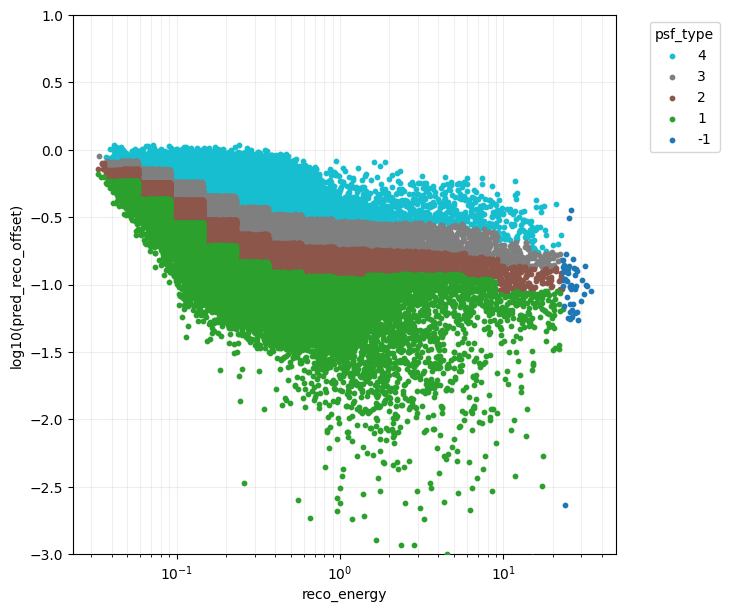

In [ ]:
classes = np.sort(sample["pred_psf_class"].dropna().unique())
n_classes = len(classes)

cmap = plt.get_cmap("tab10", n_classes)

plt.figure(figsize=(7, 7))

for i, cls in reversed(list(enumerate(classes))):
    mask = sample["pred_psf_class"] == cls
    x_vals = 10 ** sample.loc[mask, "log_reco_energy"]

    y_vals = np.log10(sample.loc[mask, "pred_reco_offset"])

    plt.scatter(
        x_vals,
        y_vals,
        color=cmap(i),
        s=10,
        label=f"{int(cls)}",
        zorder=10 + (n_classes - i)
    )

import matplotlib as mpl
norm = mpl.colors.BoundaryNorm(np.arange(n_classes + 1) - 0.5, n_classes)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.xscale("log")
plt.xlabel("reco_energy")
plt.ylim(-3, 1.0)
plt.ylabel("log10(pred_reco_offset)")
plt.grid(True, which="both", alpha=0.2)
plt.legend(title="pred_psf_class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
cols = ["obs_id", "event_id", "x", "y", "reco_offset", "psf_class","pred_psf_class", "pred_reco_offset"]

In [20]:
sample[cols].sort_values(by="event_id")

,obs_id,event_id,x,y,reco_offset,psf_class,psf_type,pred_reco_offset
82496,7208,101,-0.181574,0.297827,0.543868,4,2,0.480875
51055,13808,101,-0.499954,0.423156,0.061030,1,3,0.257788
59358,9008,104,0.346142,0.750298,0.322724,4,2,0.181405
160990,12008,104,0.763662,0.080192,0.966492,4,3,0.651057
58758,9008,106,-0.232784,-0.485326,0.353395,4,2,0.169603
...,...,...,...,...,...,...,...,...
88167,15208,1999309,0.421114,0.792198,0.054953,1,1,0.077899
54885,10308,1999509,0.029609,-0.684320,0.241533,3,1,0.126500
72548,6508,1999607,0.384260,0.299643,0.053068,1,1,0.033236
129166,5308,1999608,0.235001,0.915098,0.182959,3,4,0.313872


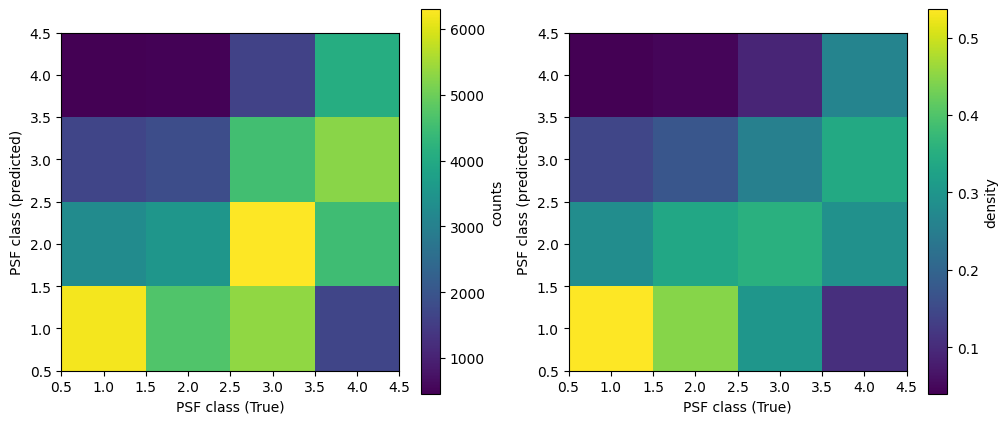

In [ ]:
from matplotlib import pyplot
pyplot.figure(figsize=(12, 5))

pyplot.subplot(121, aspect='equal')
pyplot.xlabel('PSF class (True)')
pyplot.ylabel('PSF class (predicted)')
pyplot.hist2d(
    sample['psf_class'].values,
    sample['pred_psf_class'].values,
    bins=(edges, edges)
);
pyplot.colorbar(label='counts')

pyplot.subplot(122, aspect='equal')
pyplot.xlabel('PSF class (True)')
pyplot.ylabel('PSF class (predicted)')
pyplot.pcolormesh(
    edges,
    edges,
    density.transpose()
);
pyplot.colorbar(label='density')

In [23]:
from astropy.coordinates import angular_separation

sample.loc[:, 'reco_offset'] = 180 / np.pi * angular_separation(
    sample['mc_az'].values,
    sample['mc_alt'].values,
    sample["reco_az"].values,
    sample["reco_alt"].values,
)

In [24]:
# sample.loc[:, 'reco_offset'] = sample.eval(
#     'sqrt((reco_src_x - src_x)**2 + (reco_src_y - src_y)**2)'
# )

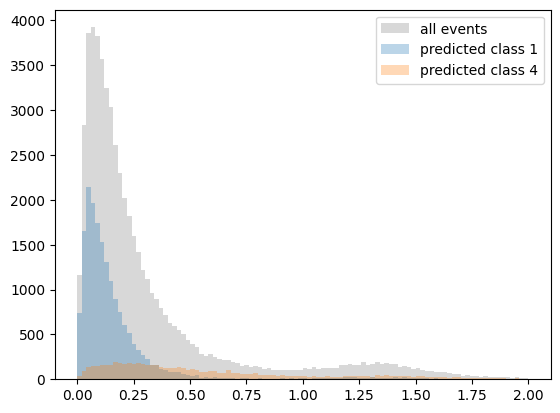

In [ ]:
# pyplot.semilogy()

pyplot.hist(
    sample['reco_offset'],#**2,
    range=(0, 2),
    bins=100,
    alpha=0.3,
    density=False,
    color='grey',
    label='all events'
);

for psf_class in (1, n_classes-1):
    pyplot.hist(
        sample['reco_offset'][sample['pred_psf_class']==psf_class],
        range=(0, 2),
        bins=100,
        density=False,
        alpha=0.3,
        label=f'predicted class {psf_class}'
    );

pyplot.legend()

In [26]:
def get_psf(data, energy_edges, containment=68):
    r = [
        np.percentile(
            data.query(f'(mc_energy > {emin}) & (mc_energy < {emax})')['reco_offset'],
            containment
        )
        if not data.query(f'(mc_energy > {emin}) & (mc_energy < {emax})').empty
        else np.nan
        for emin, emax in zip(energy_edges[:-1], energy_edges[1:])
        
    ]
    return np.array(r)

In [27]:
energy_edges = 10**np.arange(-1.5, 2, step=0.2)

r68 = get_psf(sample, energy_edges)

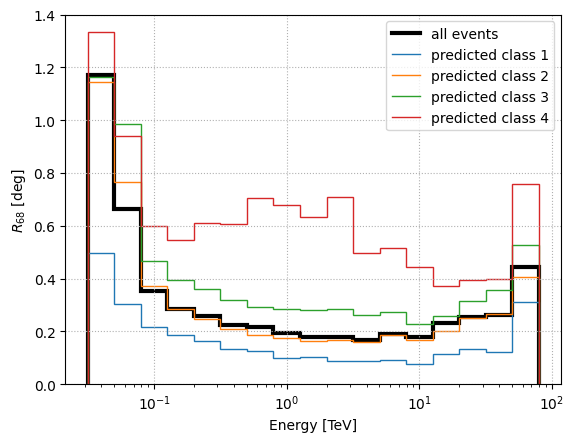

In [ ]:
pyplot.semilogx()
pyplot.xlabel('Energy [TeV]')
pyplot.ylabel('$R_{68}$ [deg]')
pyplot.ylim(0, 1.4)

pyplot.stairs(
    get_psf(sample, energy_edges),
    energy_edges,
    color='black',
    linewidth=3,
    label='all events'
)

for psf_class in (1, 2, 3, 4):
    pyplot.stairs(
        get_psf(sample[sample['pred_psf_class']==psf_class], energy_edges),
        energy_edges,
        label=f'predicted class {psf_class}'
    )

pyplot.legend()
pyplot.grid(linestyle=':')

# Create IRFs to check the bkg rates for each PSF class

In [29]:
! icapplymlp \
    -i protons/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 \
    -r 'psf_ic_mlp.pkl' \
    -c "/simulation/run_config" \
    -p 'processed/ic_' \
    --split

In [30]:
! lstchain_create_irf_files \
    --overwrite \
    -g 'GammaDiffuse/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5' \
    -p 'protons/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5' \
    -e 'GammaDiffuse/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5' \
    -o 'processed/irf.fits' \
    -c 'irf_dl3_tool_config.json' #\
    # --energy-dependent-gh

In [31]:
%%bash 

for idx in $(seq 1 4)
do
    lstchain_create_irf_files \
        --overwrite \
        -g processed/ic_gamma_part1_marked_class${idx}.h5 \
        -p processed/ic_dl2_simtel_corsika_theta_19.807_az_66.706_merged_class${idx}.h5 \
        -e processed/ic_gamma_part1_marked_class${idx}.h5 \
        -o processed/irf_MLP_class${idx}.fits \
        -c irf_dl3_tool_config.json #\
        # --energy-dependent-gh
done

# Create IRFs using optimization to check the bkg rates for each PSF class

```
python lstchain_create_optimized_cuts_irf.py --overwrite -g ./irf-classes-MLP/GammaDiffuse/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 -p ./irf-classes-MLP/protons/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 -e ./irf-classes-MLP/GammaDiffuse/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 -o ./irf-classes-MLP/irf_optimcuts.fits -c ./irf-classes-MLP/irf_dl3_tool_config.json 


for the 4 event types:

```
for idx in $(seq 1 4)
do
    python lstchain_create_optimized_cuts_irf.py \
        --overwrite \
        -g ./irf-classes-MLP/processed/ic_gamma_part1_marked_class${idx}.h5 \
        -p ./irf-classes-MLP/processed/ic_dl2_simtel_corsika_theta_19.807_az_66.706_merged_class${idx}.h5 \
        -e ./irf-classes-MLP/processed/ic_gamma_part1_marked_class${idx}.h5 \
        -o ./irf-classes-MLP/processed/irf_MLP_optimcuts_class${idx}.fits \
        -c ./irf-classes-MLP/irf_dl3_tool_config.json 
done


# Check IRFs

In [32]:
import astropy.units as u
from gammapy.irf import load_irf_dict_from_file

In [33]:
irf_ref = load_irf_dict_from_file('processed/irf.fits')

In [34]:
irf = {
    evcls: load_irf_dict_from_file(f'processed/irf_MLP_class{evcls}.fits')
    for evcls in (1, 2, 3, 4)
}

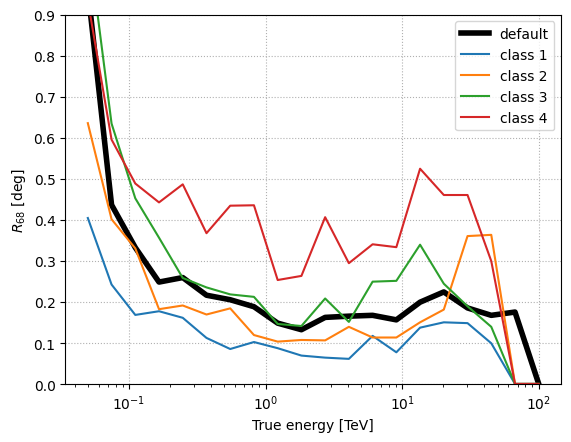

In [35]:
energy = np.geomspace(0.05, 100, num=20) * u.TeV

pyplot.semilogx()
pyplot.xlabel('True energy [TeV]')
pyplot.ylabel('$R_{68}$ [deg]')

pyplot.plot(
    energy.to('TeV').value,
    irf_ref['psf'].containment_radius(
        0.68, 
        offset=0.4*u.deg, 
        energy_true=energy
    ).to('deg').value,
    color='black',
    linewidth=4,
    label='default'
)

for evt_class in irf:
    pyplot.plot(
        energy.to('TeV').value,
        irf[evt_class]['psf'].containment_radius(
            0.68, 
            offset=0.4*u.deg, 
            energy_true=energy
        ).to('deg').value,
        label=f'class {evt_class}'
    )

pyplot.ylim(0, 0.9)
pyplot.ylim(0, None)
pyplot.grid(linestyle=':')
pyplot.legend()

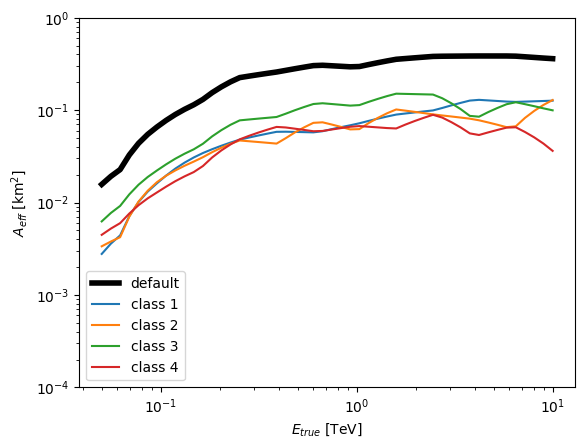

In [36]:
energy = np.geomspace(0.05, 10) * u.TeV

pyplot.loglog()
pyplot.xlabel('$E_{true}$ [TeV]')
pyplot.ylabel('$A_{eff}$ [km$^2$]')
pyplot.ylim(1e-4, 1)

pyplot.plot(
    energy.to('TeV').value,
    irf_ref['aeff'].evaluate(
        offset=0.4*u.deg, 
        energy_true=energy
    ).to('km2').value,
    color='black',
    linewidth=4,
    label='default'
)

for evt_class in irf:
    pyplot.plot(
        energy.to('TeV').value,
        irf[evt_class]['aeff'].evaluate(
            offset=0.4*u.deg, 
            energy_true=energy
        ).to('km2').value,
        label=f'class {evt_class}'
    )
    
pyplot.legend()
# pyplot.grid(linestyle=':')

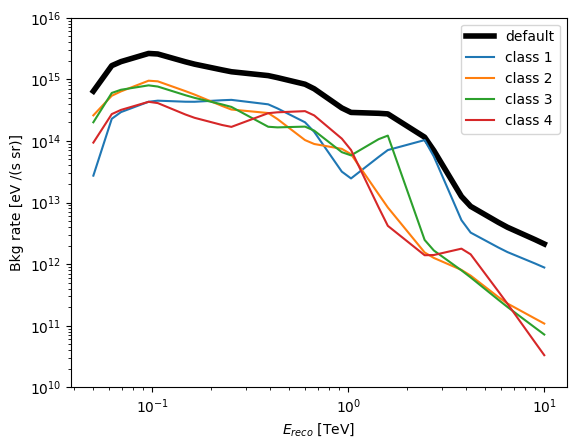

In [37]:
energy = np.geomspace(0.05, 10) * u.TeV

pyplot.loglog()
pyplot.xlabel('$E_{reco}$ [TeV]')
pyplot.ylabel('Bkg rate [eV /(s sr)]')
pyplot.ylim(1e10, 1e16)

pyplot.plot(
    energy.to('TeV').value,
    (energy**2 * irf_ref['bkg'].evaluate(
        offset=0.4*u.deg, 
        energy=energy
    )).to('eV /(s sr)').value,
    color='black',
    linewidth=4,
    label='default'
)

for evt_class in irf:
    pyplot.plot(
        energy.to('TeV').value,
        (energy**2 * irf[evt_class]['bkg'].evaluate(
            offset=0.4*u.deg, 
            energy=energy
        )).to('eV /(s sr)').value,
        label=f'class {evt_class}'
    )
    
pyplot.legend()

In [38]:
def compute_energy_resolution(edisp, energy_true, offset=0.4*u.deg, containment=0.68):
    migra = edisp.axes["migra"]
    mcenter = migra.center
#     mcenter = np.geomspace(0.1, 10, num=1000)
    resolution = np.zeros(energy_true.shape)

    for ei, energy in enumerate(energy_true):
        disp = edisp.evaluate(
            offset=offset,
            energy_true=energy,
            migra=mcenter
        )
        disp /= disp.sum()
        
        selection = np.where(
            (disp.cumsum() > 0.5 - containment/2) & (disp.cumsum() < 0.5 + containment/2)
        )
        if len(selection[0]) > 0:
            resolution[ei] = (mcenter[selection].max() - mcenter[selection].min()) / 2
        
    return resolution

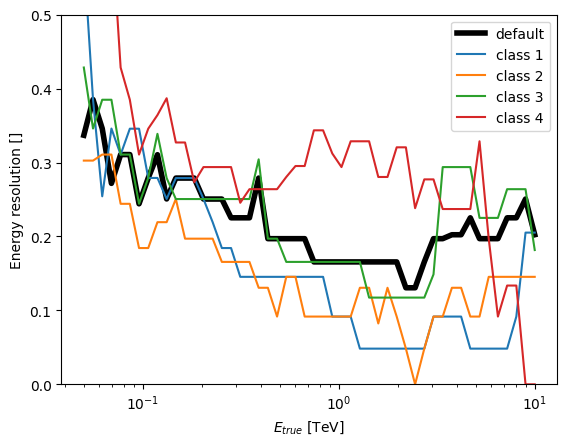

In [39]:
energy = np.geomspace(0.05, 10) * u.TeV

pyplot.semilogx()
pyplot.xlabel('$E_{true}$ [TeV]')
pyplot.ylabel('Energy resolution []')
pyplot.ylim(0.0, 0.5)

pyplot.plot(
    energy.to('TeV').value,
    compute_energy_resolution(
        irf_ref['edisp'],
        energy,
        offset=0.4*u.deg,
    ),
    color='black',
    linewidth=4,
    label='default'
)

for evt_class in irf:
    pyplot.plot(
        energy.to('TeV').value,
        compute_energy_resolution(
            irf[evt_class]['edisp'],
            energy,
            offset=0.4*u.deg,
        ),
        label=f'class {evt_class}'
    )
    
pyplot.legend()

# $\gamma$Py sensitivity estimate for a simulated Crab

Based on https://docs.gammapy.org/1.3/tutorials/analysis-3d/simulate_3d.html#sphx-glr-tutorials-analysis-3d-simulate-3d-py

In [ ]:
# Define the observation parameters (typically the observation duration and the pointing position):
livetime = 2.0 * u.hr
pointing_position = SkyCoord(83.6324, 22.4174, unit="deg", frame="icrs")
# We want to simulate an observation pointing at a fixed position in the sky.
# For this, we use the `FixedPointingInfo` class
from gammapy.data import FixedPointingInfo, PointingMode

pointing = FixedPointingInfo(
    fixed_icrs=pointing_position.icrs,
    mode=PointingMode.POINTING,
)

# Define map geometry for binned simulation
energy_reco = MapAxis.from_edges(
    np.logspace(-1.0, 1.0, 10), unit="TeV", name="energy", interp="log"
)
geom = WcsGeom.create(
    skydir=(83.6324, 22.0174),
    binsz=0.02,
    width=(3, 3),
    frame="icrs",
    axes=[energy_reco],
)
# It is usually useful to have a separate binning for the true energy axis
energy_true = MapAxis.from_edges(
    np.logspace(-1.5, 1.5, 30), unit="TeV", name="energy_true", interp="log"
)

empty = MapDataset.create(geom, name="dataset-simu", energy_axis_true=energy_true)

# Define sky model to used simulate the data.
# Here we use a Gaussian spatial model and a Power Law spectral model.
spatial_model = GaussianSpatialModel(
    lon_0="83.6324 deg", lat_0="22.0174 deg", sigma="0.01 deg", frame="icrs"
)
spectral_model = PowerLawSpectralModel(
    index=3, amplitude="1e-11 cm-2 s-1 TeV-1", reference="1 TeV"
)
model_simu = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="model-simu",
)

bkg_model = FoVBackgroundModel(dataset_name="dataset-simu")

models = Models([model_simu, bkg_model])

In [ ]:
# Create an in-memory observation
location = observatory_locations["cta_north"]
obs = Observation.create(
    pointing=pointing, livetime=livetime, irfs=irf_ref, location=location
)

# Make the MapDataset
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])

maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=4.0 * u.deg)

dataset = maker.run(empty, obs)
dataset = maker_safe_mask.run(dataset, obs)

# Add the model on the dataset and Poisson fluctuate
dataset.models = models
dataset.fake()

In [ ]:
dataset.counts.smooth(0.05 * u.deg).plot_interactive(add_cbar=True, stretch="linear")
plt.show()

# Sensitivity curves

In [60]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt

from IPython.display import display
from gammapy.data import FixedPointingInfo, Observation, observatory_locations
from gammapy.datasets import MapDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.maps import MapAxis, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    FoVBackgroundModel,
    GaussianSpatialModel,
    Models,
    PowerLawSpectralModel,
    SkyModel,
)

In [61]:
import astropy.units as u
from gammapy.irf import load_irf_dict_from_file

In [62]:
irf_ref = load_irf_dict_from_file('processed_f-50_50_p-25_50_75/irf.fits')

In [63]:
irfs = {
    evcls: load_irf_dict_from_file(f'processed_f-50_50_p-25_50_75/irf_MLP_class{evcls}.fits')
    for evcls in (1, 2, 3, 4)
}

In [64]:
import astropy
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord
from regions import CircleSkyRegion

from gammapy.datasets import MapDatasetEventSampler

from gammapy.data import DataStore
from gammapy.datasets import (
    Datasets,
    FluxPointsDataset,
    SpectrumDataset,
    SpectrumDatasetOnOff,
)
from gammapy.estimators import FluxPointsEstimator, SensitivityEstimator
from gammapy.estimators.utils import resample_energy_edges
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
)
from gammapy.maps import MapAxis, RegionGeom, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ExpCutoffPowerLawSpectralModel,
    LogParabolaSpectralModel,
    SkyModel,
    PointSpatialModel,
    create_crab_spectral_model,
)

In [65]:
from gammapy.visualization import plot_spectrum_datasets_off_regions

In [66]:
energy_axis = MapAxis.from_energy_bounds(0.03 * u.TeV, 30 * u.TeV, nbin=20)
energy_axis_true = MapAxis.from_energy_bounds(
    0.01 * u.TeV, 100 * u.TeV, nbin=100, name="energy_true"
)

pointing = SkyCoord(ra=0 * u.deg, dec=0 * u.deg)
pointing_info = FixedPointingInfo(fixed_icrs=pointing)
offset = 0.5 * u.deg

source_position = pointing.directional_offset_by(0 * u.deg, offset)
on_region_radius = 0.1 * u.deg
on_region = CircleSkyRegion(source_position, radius=on_region_radius)

geom = RegionGeom.create(on_region, axes=[energy_axis])

location = observatory_locations["cta_north"]
livetime = 50.0 * u.h

maker = SpectrumDatasetMaker(selection=["exposure", "background", "edisp"])

In [67]:
# Define the models (Crab Nebula)
spectral_model = PowerLawSpectralModel(index=2.62)
crab_model = SkyModel(
    spectral_model=spectral_model,
    name="Crab Nebula",
)
models = Models([crab_model])

In [68]:
#Sensitivity estimation with UL method 
def get_sensitivity_ul(observations):
    datasets = Datasets()
    for obs in observations:
        empty_dataset = SpectrumDataset.create(geom, energy_axis_true=energy_axis_true)
        dataset = maker.run(empty_dataset, obs)
        containment = 0.68
        # correct exposure
        dataset.exposure *= containment
        # correct background estimation
        on_radii = obs.psf.containment_radius(
            energy_true=energy_axis.center, offset=offset, fraction=containment
        )
        factor = (1 - np.cos(on_radii)) / (1 - np.cos(on_region_radius))
        dataset.background *= factor.value.reshape((-1, 1, 1))
        # Set the counts to only background
        dataset.counts = dataset.background
        dataset.counts.data = np.floor(dataset.counts.data)
        dataset.models = models
        datasets.append(dataset)
    # Estimate flux points
    fpe = FluxPointsEstimator(
        energy_edges=energy_axis.edges,
        source="Crab Nebula",
        n_sigma_ul=5,
        selection_optional=["all"],  # upper limits is one of the options included in "all"
        norm_max=1e4,  # 5000 #subir la norm_max ayuda al fit y asi no salen valores negativos de sens
    ).run(datasets)
    result = fpe.e2dnde_ul.data[:, 0, 0] * fpe.e2dnde_ul.unit
    fix_10_counts = True
    if fix_10_counts:
        back_zero = fpe.counts.data[:,0,0,0] == 0
        result[back_zero] *= 10/12.5
        
    return result

In [69]:
observations_ref = [Observation.create(
    pointing=pointing_info, irfs=irf_ref, livetime=livetime, location=location
)]

In [70]:
observations_evcls = [Observation.create(
    pointing=pointing_info, irfs=irfs[evcls], livetime=livetime, location=location
)for evcls in (1, 2, 3, 4)]

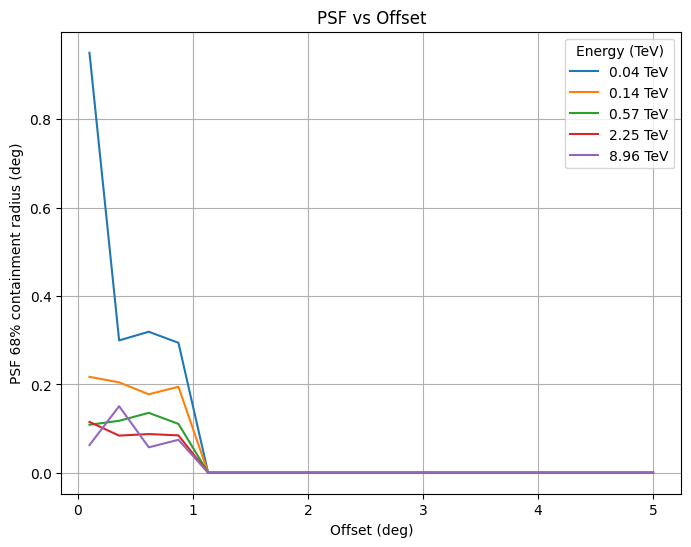

In [71]:
obs = observations_evcls[0]

offsets = np.linspace(0.1, 5.0, 20) * u.deg
energies = energy_axis.center  # already defined

plt.figure(figsize=(8, 6))

for i, energy in enumerate(energies):
    
    psf_vals = []

    for offset in offsets:
        try:
            val = obs.psf.containment_radius(
                energy_true=energy,
                offset=offset,
                fraction=0.68
            )
            psf_vals.append(val.to_value(u.deg))
        except Exception:
            psf_vals.append(np.nan)

    psf_vals = np.array(psf_vals)

    # plot only a few energies to avoid clutter
    if i % 4 == 0:
        plt.plot(
            offsets.value,
            psf_vals,
            label=f"{energy:.2f}"
        )

plt.xlabel("Offset (deg)")
plt.ylabel("PSF 68% containment radius (deg)")
plt.title("PSF vs Offset")

plt.legend(title="Energy (TeV)")
plt.grid(True)

plt.show()

In [72]:
# compute bin centers from edges
energy_centers = 0.5 * (energy_axis.edges[1:] + energy_axis.edges[:-1])


In [73]:
sens_ref = get_sensitivity_ul(observations_ref)
sens_evcls_combined = get_sensitivity_ul(observations_evcls)
sens_evcls = [
    get_sensitivity_ul([obs]) for obs in observations_evcls
]

/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)
/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)
/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)
/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimators/points/sed.py:117: GammapyDeprecationWarning: "norm_max" was deprecated in version 1.2 and will be removed in a future version. 
  super().__init__(**kwargs)
/fefs/aswg/software/conda/lib/python3.11/site-packages/gammapy/estimator

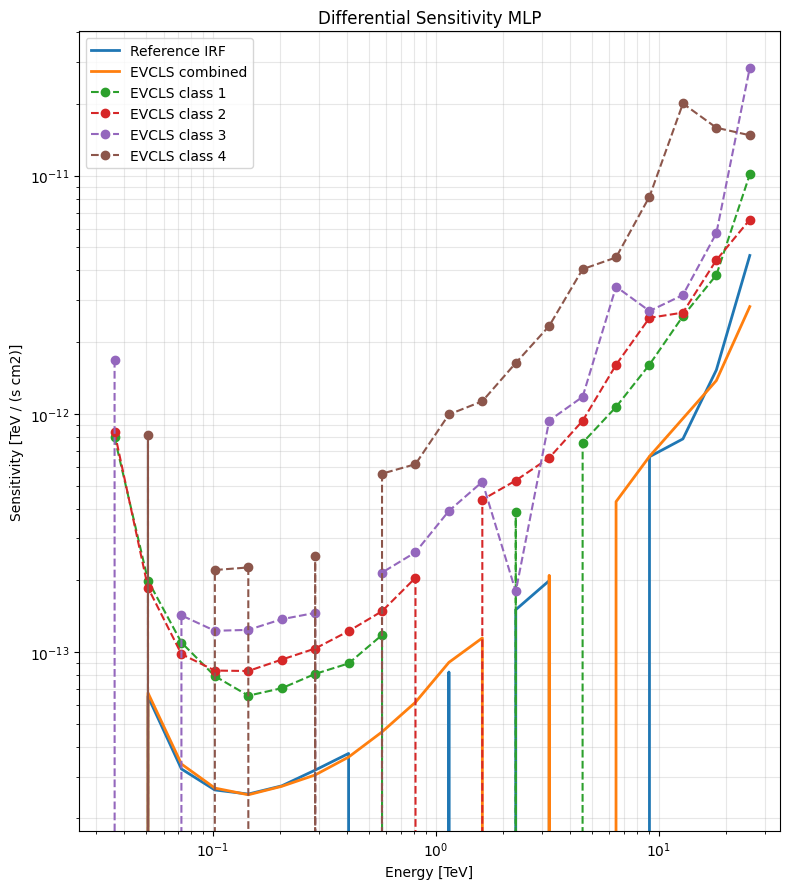

In [74]:
plt.figure(figsize=(8,9))

plt.loglog(energy_centers, sens_ref, label="Reference IRF", lw=2)

plt.loglog(
    energy_centers,
    sens_evcls_combined,
    label="EVCLS combined",
    lw=2
)

for i, sens in enumerate(sens_evcls, start=1):
    plt.loglog(
        energy_centers,
        sens,
        linestyle="--",
        marker="o",
        label=f"EVCLS class {i}"
    )

plt.xlabel(f"Energy [{energy_centers.unit}]")
plt.ylabel(f"Sensitivity [{sens_ref.unit}]")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("Differential Sensitivity MLP")
plt.xlim(2.5e-2, 35)
#plt.ylim(1e-13, 1e-9)
plt.tight_layout()
plt.savefig("sensitivities_mlp-regressor.png")
plt.show()

In [39]:
np.savez(
    "sens_MLP.npz",
    energy=energy_centers.value,
    energy_unit=str(energy_centers.unit),
    sens_ref=sens_ref.value,
    sens_evcls_combined=sens_evcls_combined.value,
    sens_evcls=np.array([s.value for s in sens_evcls]),
    flux_unit=str(sens_ref.unit)
)

In [40]:
energy_centers = 0.5 * (energy_axis.edges[1:] + energy_axis.edges[:-1])
data = np.load("sens_MLP.npz")

energy = data["energy"]
sens_ref = data["sens_ref"]
sens_evcls_combined = data["sens_evcls_combined"]
sens_evcls = data["sens_evcls"]

In [41]:
energy = data["energy"]
sens_ref = data["sens_ref"]
sens_evcls_combined = data["sens_evcls_combined"]
sens_evcls = data["sens_evcls"]

In [42]:
sens_evcls_combined

array([-1.21478647e-11,  6.73387674e-14,  3.38593768e-14,  2.68389141e-14,
        2.51564305e-14,  2.72984256e-14,  3.04694499e-14,  3.62173742e-14,
        4.62003023e-14,  6.15264134e-14,  9.04578909e-14,  1.14552796e-13,
       -3.74661005e-12,  2.09884704e-13, -2.46356962e-14,  4.27894430e-13,
        6.62717722e-13,  9.56359555e-13,  1.37994696e-12,  2.82040390e-12])

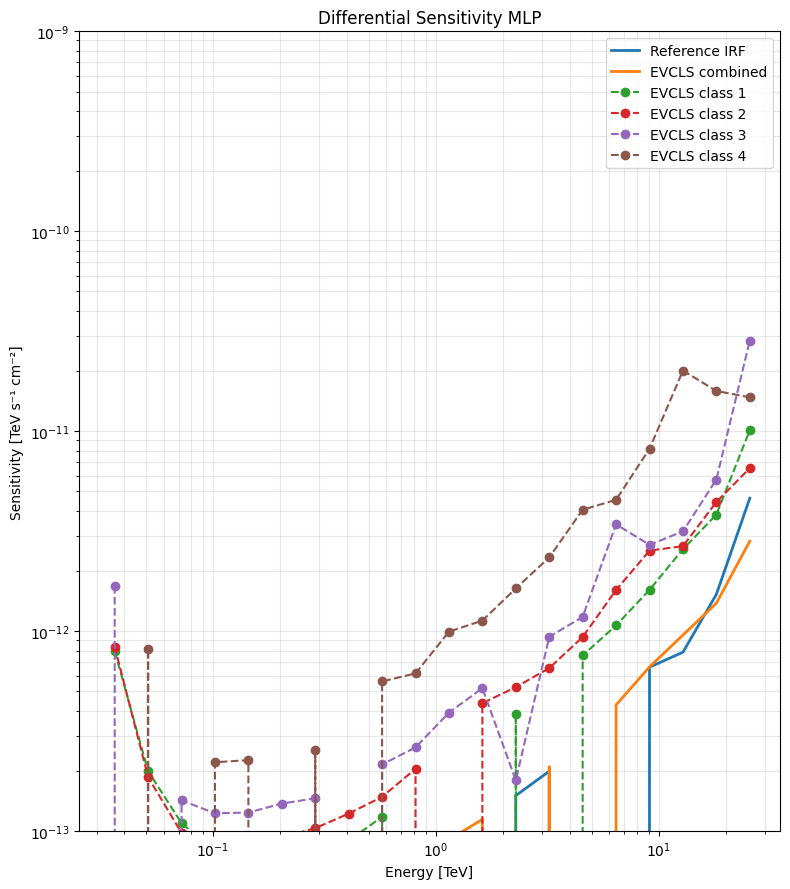

In [43]:
plt.figure(figsize=(8,9))

plt.loglog(energy_centers, sens_ref, label="Reference IRF", lw=2)

plt.loglog(
    energy_centers,
    sens_evcls_combined,
    label="EVCLS combined",
    lw=2
)

for i, sens in enumerate(sens_evcls, start=1):
    plt.loglog(
        energy_centers,
        sens,
        linestyle="--",
        marker="o",
        label=f"EVCLS class {i}"
    )

plt.xlabel(f"Energy [{energy_centers.unit}]")
plt.ylabel(f"Sensitivity [TeV s⁻¹ cm⁻²]")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("Differential Sensitivity MLP")
plt.xlim(2.5e-2, 35)
plt.ylim(1e-13, 1e-9)
plt.tight_layout()
plt.savefig("sensitivities_mlp-regressor.png")
plt.show()

#### ---------------------------------------

In [ ]:
import gammapy
print(gammapy.__version__)